In [1]:
import pandas as pd
import math

In [2]:
data = pd.read_csv("./infos-2024-02-24.tsv", sep="\t")
data.columns=['problem', 'model', 'parameter', 'conjure_mode', 'optimization_level', 'heuristic', 'solver', 'var', 'value']
data

/tmp/ipykernel_301/2869690157.py:1: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("./infos-2024-02-24.tsv", sep="\t")


,problem,model,parameter,conjure_mode,optimization_level,heuristic,solver,var,value
0,csplib-prob001-CarSequencing,CarSequencing.essence,params/generated/00032000e76ccda5fd02c1d8369f6...,portfolio4,O2,01_compact.eprime,kissat,SolverTotalTime,0.06
1,csplib-prob001-CarSequencing,CarSequencing.essence,params/generated/00032000e76ccda5fd02c1d8369f6...,portfolio4,O2,01_compact.eprime,kissat,SATClauses,101992
2,csplib-prob001-CarSequencing,CarSequencing.essence,params/generated/00032000e76ccda5fd02c1d8369f6...,portfolio4,O2,01_compact.eprime,kissat,SavileRowClauseOut,0
3,csplib-prob001-CarSequencing,CarSequencing.essence,params/generated/00032000e76ccda5fd02c1d8369f6...,portfolio4,O2,01_compact.eprime,kissat,SavileRowTotalTime,4.749
4,csplib-prob001-CarSequencing,CarSequencing.essence,params/generated/00032000e76ccda5fd02c1d8369f6...,portfolio4,O2,01_compact.eprime,kissat,SolverSatisfiable,1
...,...,...,...,...,...,...,...,...,...
616119,csplib-prob001-CarSequencing,CarSequencing.essence,params/literature/ReginPuget4.param,portfolio4,O2,06_chPrunedLevels.eprime,chuffed,SolverFailures,20888585.0
616120,csplib-prob001-CarSequencing,CarSequencing.essence,params/literature/ReginPuget4.param,portfolio4,O2,06_chPrunedLevels.eprime,chuffed,SolverSatisfiable,0.0
616121,csplib-prob001-CarSequencing,CarSequencing.essence,params/literature/ReginPuget4.param,portfolio4,O2,06_chPrunedLevels.eprime,chuffed,SavileRowTimeOut,0.0
616122,csplib-prob001-CarSequencing,CarSequencing.essence,params/literature/ReginPuget4.param,portfolio4,O2,06_chPrunedLevels.eprime,chuffed,SolverTimeOut,1.0


In [3]:
def transform(data: pd.DataFrame, columns: list)-> pd.DataFrame:
    dict_data = data.to_dict()
    keys = list(dict_data.keys())
    elements = list(dict_data[keys[0]].keys())
    dict_data = [{k: dict_data[k][e] for k in keys} for e in elements] 
    n_elements = len(dict_data)
    i = 0
    grouped = []
    extra_columns = [c for c in keys if c not in columns]
    while i < n_elements:
        current = dict_data[i]
        column_values = [current[c] for c in columns]
        extra = {}
        while column_values == [current[c] for c in columns] and i < n_elements:
            extra[current[extra_columns[0]]] = current[extra_columns[1]]
            i += 1
            if i < n_elements:
                current = dict_data[i]
        new_value = dict_data[i-1].copy()
        for c in extra_columns:
            del new_value[c]
        new_value.update(extra)
        grouped.append(new_value)
    return pd.DataFrame(grouped)
            

df = transform(data, ['problem', 'model', 'parameter', 'conjure_mode', 'optimization_level', 'heuristic', 'solver'])

In [4]:
df.loc[:,['parameter', 'optimization_level', 'heuristic', 'solver', 'SavileRowTimeOut', 'SavileRowTotalTime', 'SolverFailures', 'SolverNodes', 'SolverSatisfiable', 'SolverTimeOut', 'SolverTotalTime', 'SATClauses', 'SATVars','SavileRowClauseOut', 'SolverMemOut']].isnull().any()

parameter             False
optimization_level    False
heuristic             False
solver                False
SavileRowTimeOut      False
SavileRowTotalTime    False
SolverFailures         True
SolverNodes            True
SolverSatisfiable      True
SolverTimeOut          True
SolverTotalTime        True
SATClauses             True
SATVars                True
SavileRowClauseOut    False
SolverMemOut           True
dtype: bool

In [4]:
non_null_df = df.loc[:,
                     ['parameter', 
                      'optimization_level', 
                      'heuristic', 
                      'solver', 
                      'SavileRowTimeOut', 
                      'SavileRowTotalTime', 
                      'SolverFailures', 
                      'SolverNodes', 
                      'SolverSatisfiable', 
                      'SolverTimeOut', 
                      'SolverTotalTime', 
                      'SATClauses', 
                      'SATVars',
                      'SavileRowClauseOut', 
                      'SolverMemOut']]#.dropna(axis=1)

In [5]:
non_null_df

,parameter,optimization_level,heuristic,solver,SavileRowTimeOut,SavileRowTotalTime,SolverFailures,SolverNodes,SolverSatisfiable,SolverTimeOut,SolverTotalTime,SATClauses,SATVars,SavileRowClauseOut,SolverMemOut
0,params/generated/00032000e76ccda5fd02c1d8369f6...,O2,01_compact.eprime,kissat,0,4.749,NaN,277,1,0,0.06,101992,18664,0,NaN
1,params/generated/00032000e76ccda5fd02c1d8369f6...,O2,01_compact.eprime,chuffed,0,2.228,265941,437724,1,0,28.489,NaN,NaN,0,NaN
2,params/generated/00032000e76ccda5fd02c1d8369f6...,O2,01_compact.eprime,cplex,0,2.03,NaN,0,1,0,0.495,NaN,NaN,0,NaN
3,params/generated/00032000e76ccda5fd02c1d8369f6...,O2,02_compact.eprime,kissat,0,5.14,NaN,0,NaN,NaN,NaN,102600,18968,0,NaN
4,params/generated/00032000e76ccda5fd02c1d8369f6...,O2,02_compact.eprime,chuffed,0,3.724,200,480,1,0,0.053,NaN,NaN,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70947,params/literature/ReginPuget4.param,O2,02_compact.eprime,chuffed,0.0,2.317,39705869.0,44357774.0,0.0,1.0,3600.057,NaN,NaN,0.0,NaN
70948,params/literature/ReginPuget4.param,O2,05_nochAllLevels_2.eprime,kissat,0.0,24.193,NaN,115645629.0,NaN,NaN,3558.44,3487362.0,104734.0,0.0,NaN
70949,params/literature/ReginPuget4.param,O2,05_nochAllLevels_2.eprime,chuffed,0.0,23.755,25342452.0,39185426.0,0.0,1.0,3600.109,NaN,NaN,0.0,NaN
70950,params/literature/ReginPuget4.param,O2,06_chPrunedLevels.eprime,kissat,0.0,2.568,NaN,198728515.0,NaN,NaN,3560.85,58362.0,9934.0,0.0,NaN


### My guess is that the values for SolverNodes can be deleted while SavileRowTotalTIme and SOlverTotalTime can be aggregated together into a "TotalTime" variable. The Timeout column can be removed by multiplying by 10 each timeout. The final prediction will be the heuristic + solver option 

In [63]:
#Run this to have the dataframe with the correct transfomations already applied

non_null_df = pd.read_csv("./new_data.csv")
#non_null_df.to_csv("./new_data.csv", index=False)


In [6]:
def get_total_time(row):
    if math.isnan(float(row["SolverTotalTime"])):
        return 36000
    total_time = float(row["SolverTotalTime"]) + float(row["SavileRowTotalTime"])
    if row["SavileRowTimeOut"] == 1:
        total_time *= 10
    if not math.isnan(float(row["SolverTimeOut"])) and row["SolverTimeOut"] == 1:
        total_time *= 10
    return total_time

non_null_df["TotalTime"] = non_null_df.apply(get_total_time, axis=1)
non_null_df

,parameter,optimization_level,heuristic,solver,SavileRowTimeOut,SavileRowTotalTime,SolverFailures,SolverNodes,SolverSatisfiable,SolverTimeOut,SolverTotalTime,SATClauses,SATVars,SavileRowClauseOut,SolverMemOut,TotalTime
0,params/generated/00032000e76ccda5fd02c1d8369f6...,O2,01_compact.eprime,kissat,0,4.749,NaN,277,1,0,0.06,101992,18664,0,NaN,4.809
1,params/generated/00032000e76ccda5fd02c1d8369f6...,O2,01_compact.eprime,chuffed,0,2.228,265941,437724,1,0,28.489,NaN,NaN,0,NaN,30.717
2,params/generated/00032000e76ccda5fd02c1d8369f6...,O2,01_compact.eprime,cplex,0,2.03,NaN,0,1,0,0.495,NaN,NaN,0,NaN,2.525
3,params/generated/00032000e76ccda5fd02c1d8369f6...,O2,02_compact.eprime,kissat,0,5.14,NaN,0,NaN,NaN,NaN,102600,18968,0,NaN,36000.000
4,params/generated/00032000e76ccda5fd02c1d8369f6...,O2,02_compact.eprime,chuffed,0,3.724,200,480,1,0,0.053,NaN,NaN,0,NaN,3.777
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70947,params/literature/ReginPuget4.param,O2,02_compact.eprime,chuffed,0.0,2.317,39705869.0,44357774.0,0.0,1.0,3600.057,NaN,NaN,0.0,NaN,36023.740
70948,params/literature/ReginPuget4.param,O2,05_nochAllLevels_2.eprime,kissat,0.0,24.193,NaN,115645629.0,NaN,NaN,3558.44,3487362.0,104734.0,0.0,NaN,3582.633
70949,params/literature/ReginPuget4.param,O2,05_nochAllLevels_2.eprime,chuffed,0.0,23.755,25342452.0,39185426.0,0.0,1.0,3600.109,NaN,NaN,0.0,NaN,36238.640
70950,params/literature/ReginPuget4.param,O2,06_chPrunedLevels.eprime,kissat,0.0,2.568,NaN,198728515.0,NaN,NaN,3560.85,58362.0,9934.0,0.0,NaN,3563.418


In [27]:
def load_file(file_name):
    with open(file_name) as f:
        return f.read()
def get_dataset(df:pd.DataFrame):
    dataset = []
    for i in range(len(df)):
        row = df.iloc[i, :]
        dataset.append({
            "Parameters": load_file(row["parameter"]),
            "OptimizationLevel": row["optimization_level"],
            "Heuristic": row["heuristic"],
            "Solver": row["solver"],
            "Time": row["TotalTime"]
        })
    return dataset

dataset = get_dataset(non_null_df)

In [28]:
dataset[0]

{'Parameters': 'language Essence 1.3\n\nletting blksize_delta be\n        function(1 --> 3, 2 --> 3, 3 --> 3, 4 --> 3, 5 --> 3, 6 --> 3, 7 --> 3, 8 --> 3, 9 --> 3, 10 --> 3, 11 --> 3,\n                 12 --> 3, 13 --> 3, 14 --> 3, 15 --> 3, 16 --> 3, 17 --> 3, 18 --> 3, 19 --> 3)\nletting maxcars be\n        function(1 --> 10, 2 --> 9, 3 --> 6, 4 --> 10, 5 --> 10, 6 --> 10, 7 --> 10, 8 --> 9, 9 --> 10, 10 --> 10,\n                 11 --> 10, 12 --> 10, 13 --> 10, 14 --> 10, 15 --> 10, 16 --> 10, 17 --> 10, 18 --> 10, 19 --> 9)\nletting n_cars be 152\nletting n_classes be 2\nletting n_options be 19\nletting quantity be function(1 --> 76, 2 --> 76)\nletting usage be\n        relation((1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 8), (1, 9), (1, 10), (1, 11), (1, 12), (1, 13),\n                 (1, 14), (1, 15), (1, 16), (1, 17), (1, 18), (2, 7), (2, 19))\n$ Visualisation for usage\n$  1  1\n$  1  2\n$  1  3\n$  1  4\n$  1  5\n$  1  6\n$  1  8\n$  1  9\n$  1 10\n$  1 11\n$  1 12\n$

In [7]:
import numpy as np
import matplotlib.pyplot as plt

In [9]:
instances = np.unique(data["parameter"])  
inst_data = {inst: {} for inst in instances}
for i in range(len(non_null_df)):
    row = non_null_df.iloc[i, :]
    timeout = row["SavileRowTimeOut"]
    if row['solver'] != "or-tools":
        inst_data[row["parameter"]][f"{row['heuristic']}_{row['solver']}"] = {"t":0, "o":0, "i": row["parameter"]}

not_complete = []
k = []
for inst in inst_data.keys():
    k.append(len(list(inst_data[inst].keys())))
    if len(list(inst_data[inst].keys())) < 12:
        not_complete.append(inst)
print(len(not_complete))

9208


In [10]:
idxs = []
for i in range(len(non_null_df)):
    row = non_null_df.iloc[i, :]
    if row["parameter"] in not_complete:
        idxs.append(i)


In [11]:
trimmed = non_null_df.drop(idxs)

In [12]:
trimmed

,parameter,optimization_level,heuristic,solver,SavileRowTimeOut,SavileRowTotalTime,SolverFailures,SolverNodes,SolverSatisfiable,SolverTimeOut,SolverTotalTime,SATClauses,SATVars,SavileRowClauseOut,SolverMemOut,TotalTime
0,params/generated/00032000e76ccda5fd02c1d8369f6...,O2,01_compact.eprime,kissat,0,4.749,NaN,277,1,0,0.06,101992,18664,0,NaN,4.809
1,params/generated/00032000e76ccda5fd02c1d8369f6...,O2,01_compact.eprime,chuffed,0,2.228,265941,437724,1,0,28.489,NaN,NaN,0,NaN,30.717
2,params/generated/00032000e76ccda5fd02c1d8369f6...,O2,01_compact.eprime,cplex,0,2.03,NaN,0,1,0,0.495,NaN,NaN,0,NaN,2.525
3,params/generated/00032000e76ccda5fd02c1d8369f6...,O2,02_compact.eprime,kissat,0,5.14,NaN,0,NaN,NaN,NaN,102600,18968,0,NaN,36000.000
4,params/generated/00032000e76ccda5fd02c1d8369f6...,O2,02_compact.eprime,chuffed,0,3.724,200,480,1,0,0.053,NaN,NaN,0,NaN,3.777
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12159,params/generated/19f3832c6ed33672be771a1dd3f34...,O2,05_nochAllLevels_2.eprime,chuffed,0,57.371,200,472,1,0,0.042,NaN,NaN,0,NaN,57.413
12160,params/generated/19f3832c6ed33672be771a1dd3f34...,O2,05_nochAllLevels_2.eprime,cplex,0,54.783,NaN,0,1,0,0.268,NaN,NaN,0,NaN,55.051
12161,params/generated/19f3832c6ed33672be771a1dd3f34...,O2,06_chPrunedLevels.eprime,kissat,0,1.787,NaN,255,1,0,0.02,83528,11937,0,0,1.807
12162,params/generated/19f3832c6ed33672be771a1dd3f34...,O2,06_chPrunedLevels.eprime,chuffed,0,1.028,971367,1811233,1,0,55.930,NaN,NaN,0,NaN,56.958


In [13]:
def flatten_list(lst):
    flattened = []
    for item in lst:
        if isinstance(item, list):
            flattened.extend(flatten_list(item))
        else:
            flattened.append(item)
    return flattened

times when a given combination has been the best


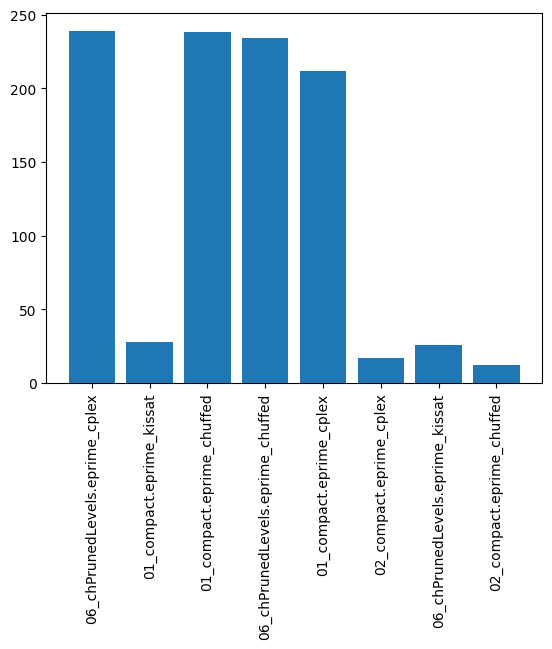

times when a given solver has been the best


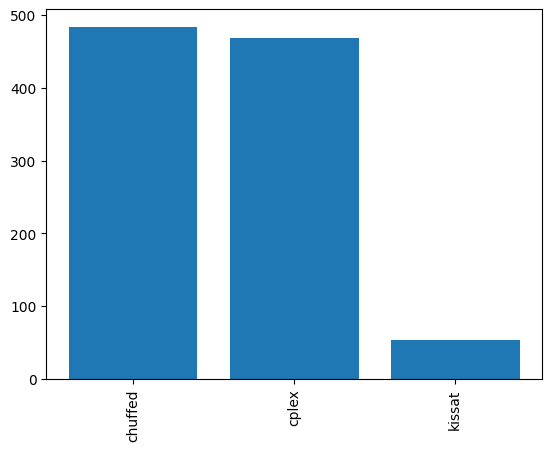

times when a given model has been the best


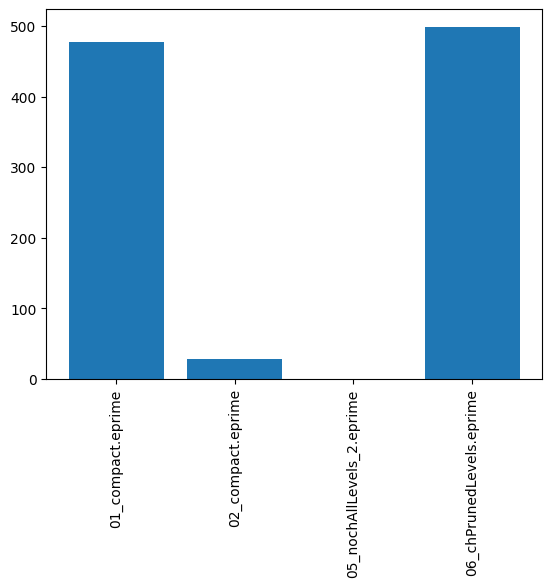

normalized distance from the best when a given combination didn't won


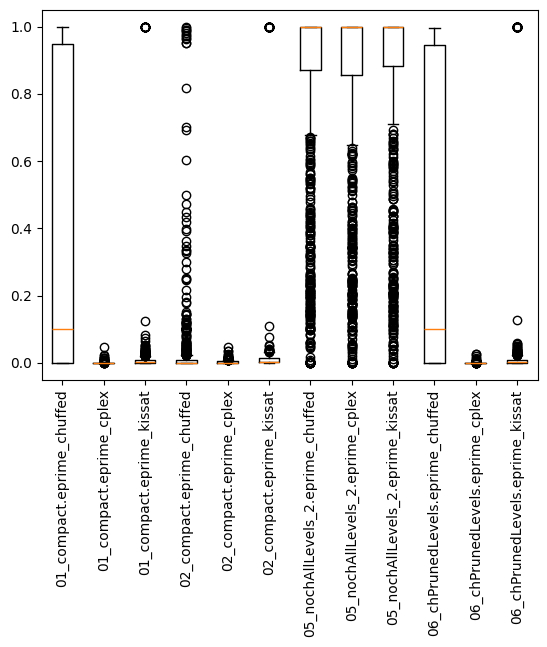

normalized distance from the best when a given model didn't won


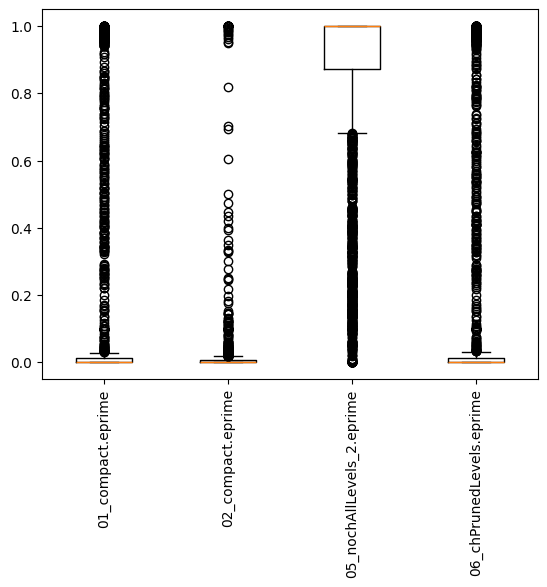

normalized distance from the best when a given solver didn't won


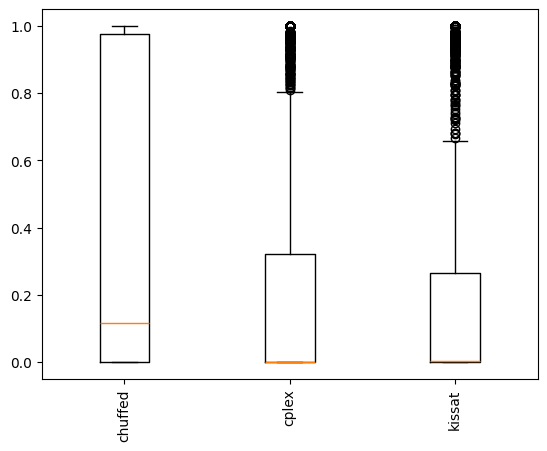

total solving time for a given combination


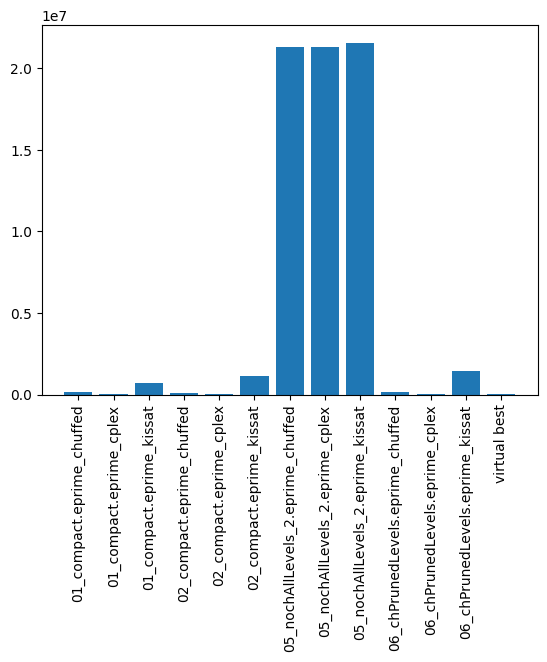

total solving time for a given model


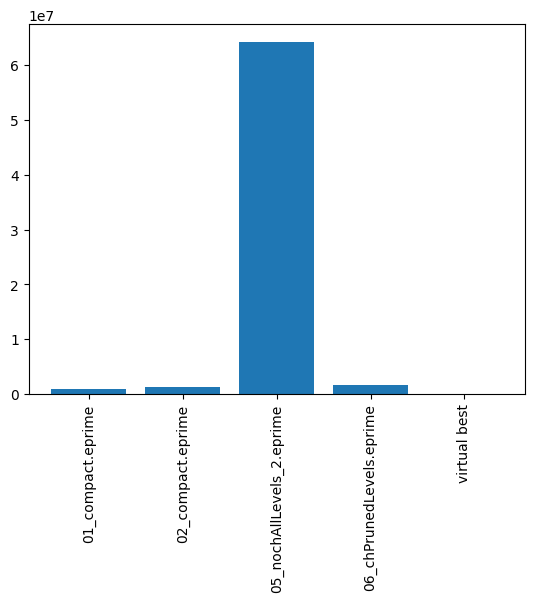

total solving time for a given solver


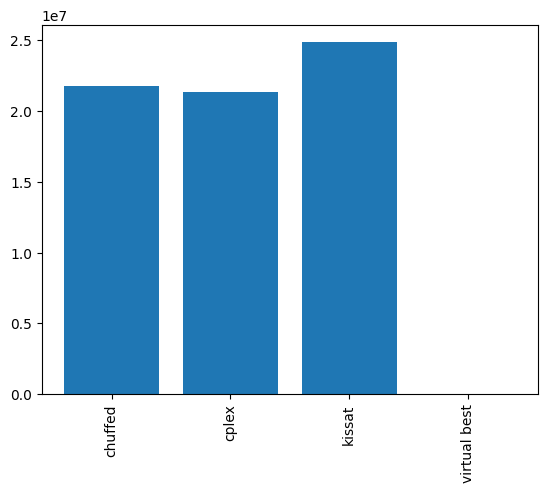

1006
5951.44


In [14]:
def make_stats(data:pd.DataFrame)-> None:
    instances = np.unique(data["parameter"])    
    inst_data = {inst: {} for inst in instances}
    for i in range(len(data)):
        row = data.iloc[i, :]
        timeout = row["SavileRowTimeOut"]
        if row["TotalTime"] > 3600:
            timeout = 1
        if row['solver'] != "or-tools":
            inst_data[row["parameter"]][f"{row['heuristic']}_{row['solver']}"] = {"t":row["TotalTime"], "o":timeout, "i": row["parameter"]}
    all_times = []
    bests = {}
    bests_all = {}
    for key in inst_data.keys():
        datapoint = inst_data[key]
        combinations = list(datapoint.keys())
        best = {'c': combinations[0], 'v': datapoint[combinations[0]]["t"], "t":datapoint[combinations[0]]["o"], "i": datapoint[combinations[0]]["i"]}

        for comb in combinations:
            all_times.append({'c': comb, 'v': datapoint[comb]["t"], "t": datapoint[comb]["o"], "i": datapoint[comb]["i"]})
            if best['v'] > datapoint[comb]["t"]:
                best = {'c': comb, 'v': datapoint[comb]["t"], "t": datapoint[comb]["o"], "i": datapoint[comb]["i"]}
        if not best['c'] in bests:
            bests[best['c']] = 0
        if best["t"] == 1:
            bests["timeout"] +=1
        else:
            bests[best['c']] +=1
        bests_all[best["i"]] = best
    
    print("times when a given combination has been the best")
    plt.bar(list(bests.keys()), list(bests.values()))
    plt.xticks(rotation=90)
    plt.show()
    solvers = np.unique(data["solver"]).tolist()
    # solvers += ["timeout"]
    solv_data = {s: 0 for s in solvers}
    # del solv_data["or-tools"]
    for best in bests.keys():
        for solver in solvers:
            if solver in best:
                solv_data[solver] += bests[best]
    print("times when a given solver has been the best")
    plt.bar(list(solv_data.keys()), list(solv_data.values()))
    plt.xticks(rotation=90)
    plt.show()
    heuristics = np.unique(data["heuristic"]).tolist()
    # heuristics += ["timeout"]
    heur_data = {h: 0 for h in heuristics}
    for best in bests.keys():
        for heur in heuristics:
            if heur in best:
                heur_data[heur] += bests[best]
    print("times when a given model has been the best")
    plt.bar(list(heur_data.keys()), list(heur_data.values()))
    plt.xticks(rotation=90)
    plt.show()
    distances_total = {d: [] for d in np.unique(flatten_list([list(inst_data[key].keys()) for key in inst_data.keys()]))}
    distances_heuristic = {d: [] for d in heuristics}
    distances_solvers = {d: [] for d in solvers}
    # del distances_solvers["or-tools"]
    maxes = {}
    for bf in all_times:
        if not bf["i"] in maxes:
            maxes[bf["i"]] = bf["v"]
        if maxes[bf["i"]] < bf["v"]:
            maxes[bf["i"]] = bf["v"]

    for bf in all_times:
        if bests_all[bf["i"]]["v"] != bf["v"]:
            normalized_distance = (bf["v"] - bests_all[bf["i"]]["v"]) / maxes[bf["i"]]
            distances_total[bf["c"]].append(normalized_distance)
            for h in heuristics:
                if h in bf["c"]:
                    distances_heuristic[h].append(normalized_distance)
            for s in solvers:
                if s in bf["c"]:
                    distances_solvers[s].append(normalized_distance)
    print("normalized distance from the best when a given combination didn't won")
    plt.boxplot(list(distances_total.values()), labels=list(distances_total.keys()))
    plt.xticks(rotation=90)
    plt.show()
    print("normalized distance from the best when a given model didn't won")
    plt.boxplot(list(distances_heuristic.values()), labels=list(distances_heuristic.keys()))
    plt.xticks(rotation=90)
    plt.show()
    print("normalized distance from the best when a given solver didn't won")
    plt.boxplot(list(distances_solvers.values()), labels=list(distances_solvers.keys()))
    plt.xticks(rotation=90)
    plt.show()
    total_time_total = {d: 0 for d in np.unique(flatten_list([list(inst_data[key].keys()) for key in inst_data.keys()]))}
    total_time_heuristic = {d: 0 for d in heuristics}
    total_time_solvers = {d: 0 for d in solvers}
    # del total_time_solvers["or-tools"]
    for bf in all_times:
        total_time_total[bf["c"]] += bf["v"]
        for h in heuristics:
            if h in bf["c"]:
                total_time_heuristic[h] += bf["v"]
        for s in solvers:
            if s in bf["c"]:
                total_time_solvers[s] += bf["v"]
    vb = np.sum([bests_all[key]["v"] for key in bests_all.keys()])
    total_time_total["virtual best"] = vb
    total_time_heuristic["virtual best"] = vb
    total_time_solvers["virtual best"] = vb
    print("total solving time for a given combination")
    plt.bar(list(total_time_total.keys()), list(total_time_total.values()))
    plt.xticks(rotation=90)
    plt.show()
    print("total solving time for a given model")
    plt.bar(list(total_time_heuristic.keys()), list(total_time_heuristic.values()))
    plt.xticks(rotation=90)
    plt.show()
    print("total solving time for a given solver")
    plt.bar(list(total_time_solvers.keys()), list(total_time_solvers.values()))
    plt.xticks(rotation=90)
    plt.show()
    print(len([bests_all[key]["v"] for key in bests_all.keys()]))
    print(vb)
make_stats(trimmed)

In [2]:
from transformers import BertTokenizer, BertModel
import torch.nn as nn
import torch
from typing import Tuple, Literal
from sys import stdout

In [3]:
class NeuralNetwork(nn.Module):
  """
  This class implements a simple interface to get a working neural network using pytorch.
  """
  def __init__(self) -> None:
     super().__init__()
  def train_network(self,
            train_loader:torch.utils.data.DataLoader,
            validation_loader:torch.utils.data.DataLoader,
            optimizer = torch.optim.Adam, 
            loss_function = nn.CrossEntropyLoss(),
            learning_rate:float=.1,
            epochs:int=10,
            device:str='cpu',
            output_extraction_function:callable = lambda x: torch.round(x).detach().cpu(),
            metrics:dict[str,callable] = {},
            verbose:bool=False,
            automatically_handle_gpu_memory:bool = True) -> Tuple[dict[str,list[float]],dict[str,list[float]]]:
    """
      A simple training loop for the neural network. It returns the epochs loss and accuracy history both on the training and the validation set. The tuple will be formatted as:
      train loss, train accuracy, val loss, val accuracy
      Parameters
      ----------
      train_loader: torch.utils.data.DataLoader
        A dataloader containing the dataset that will be used for training the network
      validation_loader: torch.utils.data.DataLoader
        A dataloader containing the dataset that will be used for validate the network at the end of each epoch
      optimizer:
        The optimizer to use while training, default to Adam.
      loss_function:
        The loss function to use while training, default to crossentropy
      learning_rate: float
        The learning rate that will be used in the optimizer to train the network. Default to .1
      epochs: int
        The number of training epochs, default to 10.
      device: str
        The device to use for the computation
      metrics: dict[str,callable]
        The metrics to use to evaluate the network
      verbose: bool
        Determines if intermidiate values of training statistics will be printed to stdout
      automatically_handle_gpu_memory: bool
        Determines if the training function should handle the moving of the data from e to the gpu memory (both the model and the training/validation data)
    """
    old_device = next(self.parameters()).device
    if next(self.parameters()).device == device or not automatically_handle_gpu_memory:
      net = self
    else:
      net = self.to(device)
    optimizer = optimizer(net.parameters(), learning_rate)

    train_loss_history = []
    val_loss_history = []

    total_batch = int(len(train_loader.dataset) / train_loader.batch_size)
    train_metrics_scores = {}
    val_metrics_scores = {}
    for key in metrics:
        train_metrics_scores[key] = []
        val_metrics_scores[key] = []

    for epoch in range(epochs):
        net.train()
        for batch_idx, data in enumerate(train_loader):
            labels = data[1]
            inputs = data[0]
            if automatically_handle_gpu_memory:
              labels = data[1].to(device)
              inputs = self.__to(data[0], device)
            outputs = net(inputs)
            loss = loss_function(outputs, labels)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            predicted_classes = output_extraction_function(outputs)
            normal_labels = output_extraction_function(labels)
            if verbose:
              stdout.write(f"\rbatch {batch_idx + 1}/{total_batch} ----- loss: {loss.cpu()} ----- {'-----'.join([f'{key}: {metrics[key](predicted_classes, normal_labels)}' for key in metrics.keys()])}")
              stdout.flush()
            if automatically_handle_gpu_memory:
              self.__remove(inputs)
              del labels
              torch.cuda.empty_cache()

        val_metrics, val_loss = self.__validate(validation_loader, metrics, loss_function, device, output_extraction_function, automatically_handle_gpu_memory)
        for key in metrics:
          val_metrics_scores[key].append(val_metrics[key])
        val_loss_history.append(val_loss)
        train_metrics, train_loss = self.__validate(train_loader, metrics, loss_function, device, output_extraction_function, automatically_handle_gpu_memory)
        for key in metrics:
          train_metrics_scores[key].append(train_metrics[key])
        train_loss_history.append(train_loss)
        if verbose:
          out_str = f"EPOCH {epoch + 1} training loss: {train_loss_history[-1]} - validation loss: {val_loss_history[-1]}\n" + \
          '\n'.join([f"EPOCH {epoch + 1} training {metric}: {train_metrics_scores[metric][-1]} - validation {metric}: {val_metrics_scores[metric][-1]}" for metric in metrics.keys()]) +\
          f"\n{'-'*100}\n"
          stdout.write("\r" + " " * len(out_str) + "\r")
          stdout.flush()
          stdout.write(out_str)
          stdout.flush()
          print()
    train_metrics_scores['loss'] = train_loss_history
    val_metrics_scores['loss'] = val_loss_history

    if next(self.parameters()).device != old_device and automatically_handle_gpu_memory:
      del net
      self = self.to(old_device)
      torch.cuda.empty_cache()

    return train_metrics_scores, val_metrics_scores
  
  def __to(self, data, device):
    if isinstance(data, dict):
      return {key: self.__to(data[key], device) for key in data.keys()}
    elif isinstance(data, list):
      return [self.__to(d, device) for d in data]
    elif isinstance(data, tuple):
      return tuple([self.__to(d, device) for d in data])
    else:
      return data.to(device)
    
  def __remove(self, data):
    if isinstance(data, dict):
      for key in data.keys():
        self.__remove(data[key])
    elif isinstance(data, list) or isinstance(data, tuple):
      for d in data:
        self.__remove(d)
    else:
      del data

  def __validate(self, loader, metrics, loss_function, device, output_extraction_function, automatically_handle_gpu_memory):
    losses = []
    metrics_scores = {}
    for key in metrics.keys():
      metrics_scores[key] = []
    net = self.to(device)
    net.eval()
    with torch.no_grad():
        for batch_idx, data in enumerate(loader):
          labels = data[1]
          inputs = data[0]
          if automatically_handle_gpu_memory:
            inputs = self.__to(data[0], device)
            labels = data[1].to(device)
          outputs = net(inputs)
          loss = loss_function(outputs, labels)
          losses.append(loss)
          predicted_classes = output_extraction_function(outputs)
          real_labels = output_extraction_function(labels)
          for key in metrics.keys():
            metrics_scores[key].append(metrics[key](predicted_classes, real_labels))
          if automatically_handle_gpu_memory:
            self.__remove(inputs)
            del labels
            torch.cuda.empty_cache()

    average_loss = sum(losses)/(batch_idx+1)
    mean_metrics_scores = {}
    for key in metrics.keys():
      mean_metrics_scores[key] = sum(metrics_scores[key])/len(loader)
    return mean_metrics_scores, average_loss